# **Unit 4 Lecture 3: 3D Motion and CNC Kinematics**

**Dynamics of Structures and Machines** | Mechatronics Engineering | Semester 4

---

## **Learning Outcomes**

By the end of this lecture, you will be able to:

1. **Decompose 3D motion** into independent x, y, z components in Cartesian coordinates
2. **Calculate motor speeds** required for desired end-effector velocity in CNC/3D printer
3. **Apply acceleration constraints** to generate smooth motion profiles (trapezoidal, S-curve)
4. **Generate toolpaths** for 3D printing and CNC machining applications
5. **Visualize 3D trajectories** with velocity vectors and understand path planning

---

## **Real-World Context**

**Applications:**
- **3D Printing**: FDM printers (Prusa, Ender 3)
- **CNC Machining**: Mills, lathes, routers
- 🤖 **Industrial Robots**: Cartesian gantry systems
- **Medical Devices**: Surgical robots, CT scanners

**Connection to Previous Lectures:**
- L1: Constraints now in 3D space
- L2: Multiple motors (like pulleys)
- Unit 2: Polar → Cartesian coordinates

---

![CNC Machine Coordinate System \u2014 Independent X, Y, Z Axes](figs/U4_L3_cnc_axes.png)

In [1]:
# Library imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

print(" Libraries imported successfully!")
print(" Ready to visualize 3D motion...")

 Libraries imported successfully!
 Ready to visualize 3D motion...


# Part 1: 3D Kinematics Fundamentals

## **Position, Velocity, and Acceleration in 3D**

### **Position Vector**
$$\mathbf{r}(t) = x(t)\,\hat{\mathbf{i}} + y(t)\,\hat{\mathbf{j}} + z(t)\,\hat{\mathbf{k}}$$

### **Velocity Vector**
$$\mathbf{v}(t) = \frac{d\mathbf{r}}{dt} = v_x\,\hat{\mathbf{i}} + v_y\,\hat{\mathbf{j}} + v_z\,\hat{\mathbf{k}}$$

**Key insight**: Unit vectors $\hat{\mathbf{i}}, \hat{\mathbf{j}}, \hat{\mathbf{k}}$ are constant (not rotating)!

### **Acceleration Vector**
$$\mathbf{a}(t) = \frac{d\mathbf{v}}{dt} = a_x\,\hat{\mathbf{i}} + a_y\,\hat{\mathbf{j}} + a_z\,\hat{\mathbf{k}}$$

### **Speed (Scalar)**
$$v = |\mathbf{v}| = \sqrt{v_x^2 + v_y^2 + v_z^2}$$

This is the **feed rate** in CNC machining.

### **Independent Axes**
Motion in x, y, z **decouples** - each axis is independent!
$$\frac{d^2x}{dt^2} = f_x(x, \dot{x}, t) \quad \text{(independent of } y, z)$$

Not true for polar/spherical coordinates (Unit 5).


Helical Trajectory Analysis
Radius: 20.0 mm
Pitch: 30.00 mm/revolution
Speed: 43.07 mm/s (constant!)


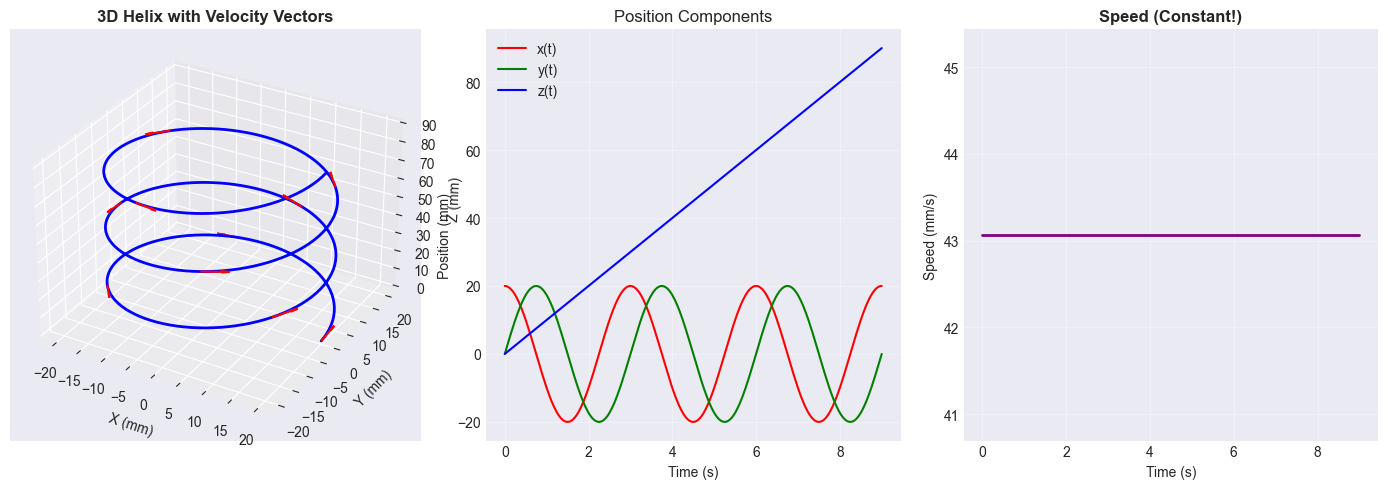


 Helix visualized!


In [2]:
# 3D Helical Trajectory

# Parameters
R = 20.0 # Radius (mm)
omega = 2 * np.pi / 3 # Angular freq (rad/s)
v_z = 10.0 # Vertical speed (mm/s)
t_total = 9.0 # Total time (3 turns)

# Time array
t = np.linspace(0, t_total, 300)

# Position
x = R * np.cos(omega * t)
y = R * np.sin(omega * t)
z = v_z * t

# Velocity
v_x = -R * omega * np.sin(omega * t)
v_y = R * omega * np.cos(omega * t)
v_z_arr = v_z * np.ones_like(t)

# Speed
speed = np.sqrt(v_x**2 + v_y**2 + v_z_arr**2)

print("Helical Trajectory Analysis")
print(f"Radius: {R} mm")
print(f"Pitch: {2*np.pi*v_z/omega:.2f} mm/revolution")
print(f"Speed: {speed[0]:.2f} mm/s (constant!)")

# Plot
fig = plt.figure(figsize=(14, 5))

# 3D path
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(x, y, z, 'b-', linewidth=2)
indices = np.arange(0, len(t), 30)
for i in indices:
 ax1.quiver(x[i], y[i], z[i], v_x[i], v_y[i], v_z_arr[i],
 length=5, normalize=True, color='red', arrow_length_ratio=0.3)
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title('3D Helix with Velocity Vectors', fontweight='bold')

# Position vs time
ax2 = fig.add_subplot(132)
ax2.plot(t, x, 'r-', label='x(t)')
ax2.plot(t, y, 'g-', label='y(t)')
ax2.plot(t, z, 'b-', label='z(t)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position (mm)')
ax2.set_title('Position Components')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Speed
ax3 = fig.add_subplot(133)
ax3.plot(t, speed, 'purple', linewidth=2)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Speed (mm/s)')
ax3.set_title('Speed (Constant!)', fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Helix visualized!")

---
### What This Graph Tells You

**3D Trajectory (left):** The helix combines circular motion in the XY-plane with a constant rise in Z. The velocity vectors (arrows) are always **tangent** to the curve — the tool tip never moves radially inward or outward.

**Position Components (middle):** Notice that $x(t)$ and $y(t)$ are sinusoidal (circular motion), while $z(t)$ increases linearly. This is **Cartesian decoupling** — each axis can be controlled by its own independent motor.

**Speed (right):** Speed is **CONSTANT** even though the direction continuously changes. This is critical for CNC: the tool cuts at uniform feed rate even on curved paths, ensuring consistent surface finish.

**Key Observations:**
- The helix is a superposition of two simple motions: circular (XY) + linear (Z)
- Each motor only needs to track its own component: $v_x = -R\omega\sin(\omega t)$, $v_y = R\omega\cos(\omega t)$, $v_z = \text{const}$
- Total speed: $|v| = \sqrt{v_x^2 + v_y^2 + v_z^2} = \sqrt{R^2\omega^2 + v_z^2}$ = constant

> **Student Takeaway:** In Cartesian coordinates, 3D motion decomposes into three independent 1D motions. Each CNC axis motor only needs to track its own velocity component — this is why Cartesian robots are the simplest to control.

# Part 2: Motor Control and Velocity Mapping

## **From Toolpath to Motor Speeds**

### **Cartesian Robot: Direct Mapping**
3 independent motors control x, y, z axes.

**Motor speeds:**
$$\omega_x = \frac{v_x}{p_x}, \quad \omega_y = \frac{v_y}{p_y}, \quad \omega_z = \frac{v_z}{p_z}$$

where $p$ = lead screw pitch (mm/revolution)

### **Feed Rate**
$$F = |\mathbf{v}| = \sqrt{v_x^2 + v_y^2 + v_z^2}$$

Given direction $\hat{\mathbf{u}}$ and feed rate $F$:
$$v_x = F \cdot \hat{u}_x, \quad v_y = F \cdot \hat{u}_y, \quad v_z = F \cdot \hat{u}_z$$

### **Motor Speed Limits**
$$|v_x| \leq v_{x,\max}, \quad |v_y| \leq v_{y,\max}, \quad |v_z| \leq v_{z,\max}$$


Straight Line Move
Distance: 115.76 mm
Motor speeds: vₓ=43.19, vᵧ=21.60, vᵧ=12.96 mm/s
Time: 2.32 s


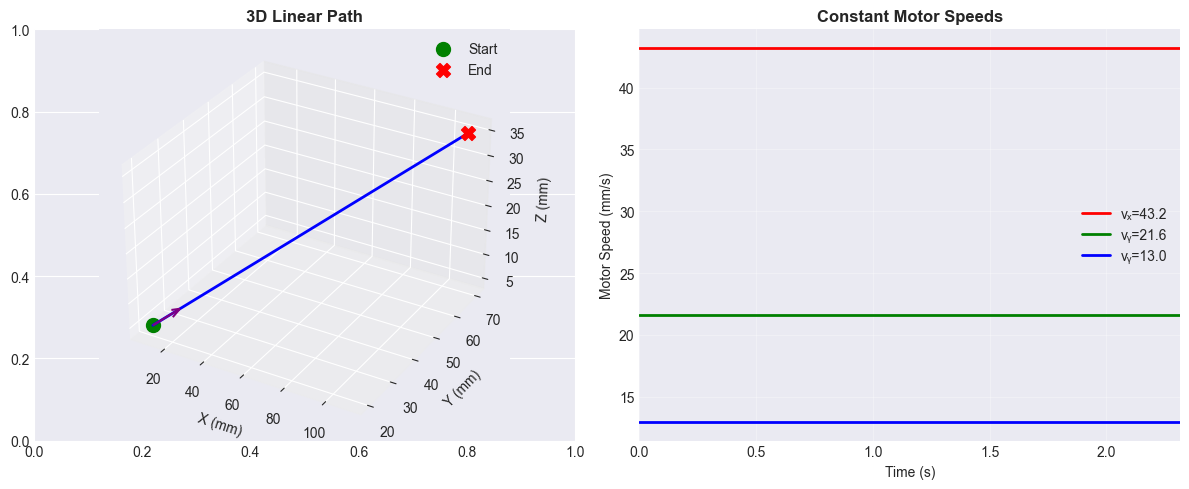


 Linear motion complete!


In [3]:
# Straight Line Motion: Motor Speed Calculation

# Two points in 3D
P0 = np.array([10.0, 20.0, 5.0]) # Start (mm)
P1 = np.array([110.0, 70.0, 35.0]) # End (mm)
F = 50.0 # Feed rate (mm/s)

# Direction and motor speeds
delta = P1 - P0
distance = np.linalg.norm(delta)
u_hat = delta / distance
v_x = F * u_hat[0]
v_y = F * u_hat[1]
v_z = F * u_hat[2]
T = distance / F

print("Straight Line Move")
print(f"Distance: {distance:.2f} mm")
print(f"Motor speeds: vₓ={v_x:.2f}, vᵧ={v_y:.2f}, vᵧ={v_z:.2f} mm/s")
print(f"Time: {T:.2f} s")

# Generate trajectory
t_line = np.linspace(0, T, 100)
position = P0[:, np.newaxis] + (delta[:, np.newaxis] / T) * t_line

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3D path
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(position[0], position[1], position[2], 'b-', linewidth=2)
ax1.scatter(*P0, color='green', s=100, marker='o', label='Start')
ax1.scatter(*P1, color='red', s=100, marker='X', label='End')
ax1.quiver(P0[0], P0[1], P0[2], v_x, v_y, v_z, 
 length=10, normalize=True, color='purple', arrow_length_ratio=0.3)
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_zlabel('Z (mm)')
ax1.set_title('3D Linear Path', fontweight='bold')
ax1.legend()

# Velocity components
ax2 = axes[1]
ax2.axhline(v_x, color='r', linewidth=2, label=f'vₓ={v_x:.1f}')
ax2.axhline(v_y, color='g', linewidth=2, label=f'vᵧ={v_y:.1f}')
ax2.axhline(v_z, color='b', linewidth=2, label=f'vᵧ={v_z:.1f}')
ax2.set_xlim(0, T)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Motor Speed (mm/s)')
ax2.set_title('Constant Motor Speeds', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Linear motion complete!")

---
### What This Graph Tells You

**3D Path:** The straight line from $P_0$ to $P_1$ is the simplest CNC move (G-code G01: linear interpolation). The velocity vector is constant in both magnitude and direction.

**Motor Velocities (bar chart):** Each motor speed is proportional to its axis's share of the total distance. The direction cosines determine the split:
$$v_x = F \cdot \frac{\Delta x}{D}, \quad v_y = F \cdot \frac{\Delta y}{D}, \quad v_z = F \cdot \frac{\Delta z}{D}$$

**Key Observations:**
- All three motors run at **different constant speeds**, but they **start and stop simultaneously** — this coordination creates a perfectly straight line
- The motor with the largest displacement runs fastest
- If any single motor hits its speed limit, the feed rate $F$ must be reduced for all axes

> **Student Takeaway:** For straight-line CNC moves, calculate the unit direction vector first, then multiply by feed rate to get each motor's speed. This is inverse kinematics for Cartesian systems — the simplest case.

# Part 3: Acceleration Constraints

## **Why Acceleration Matters**

**Motor torque limits acceleration:**
$$\tau = I\alpha \quad \Rightarrow \quad a = \frac{p\tau}{2\pi I}$$

**Typical values:**
- 3D printer: aₘₐₓ ≈ 500-2000 mm/s²
- CNC mill: aₘₐₓ ≈ 2000-10000 mm/s²
- Pick-and-place: aₘₐₓ ≈ 5000-20000 mm/s²

### **Trapezoidal Velocity Profile**

Three phases:
1. **Acceleration**: $a = a_m$, $v$ increases linearly
2. **Constant velocity**: $a = 0$, $v = v_m$
3. **Deceleration**: $a = -a_m$, $v$ decreases linearly

**Time calculation:**
$$t_1 = \frac{v_m}{a_m}, \quad d_1 = \frac{v_m^2}{2a_m}$$

**Short move** (if $d < v_m^2/a_m$):
$$v_{peak} = \sqrt{a_m \cdot d}, \quad t_{total} = 2\sqrt{\frac{d}{a_m}}$$

**Jerk** $j = da/dt$ causes vibrations → use S-curve for smoother motion.


![Trapezoidal Velocity Profile \u2014 Acceleration, Constant Speed, and Deceleration Phases](figs/U4_L3_trapezoidal_profile.png)

Trapezoidal Velocity Profiles

Long move (200mm): v_peak=100.0 mm/s, time=2.20s
Short move (50mm): v_peak=100.0 mm/s (< v_max), time=0.70s


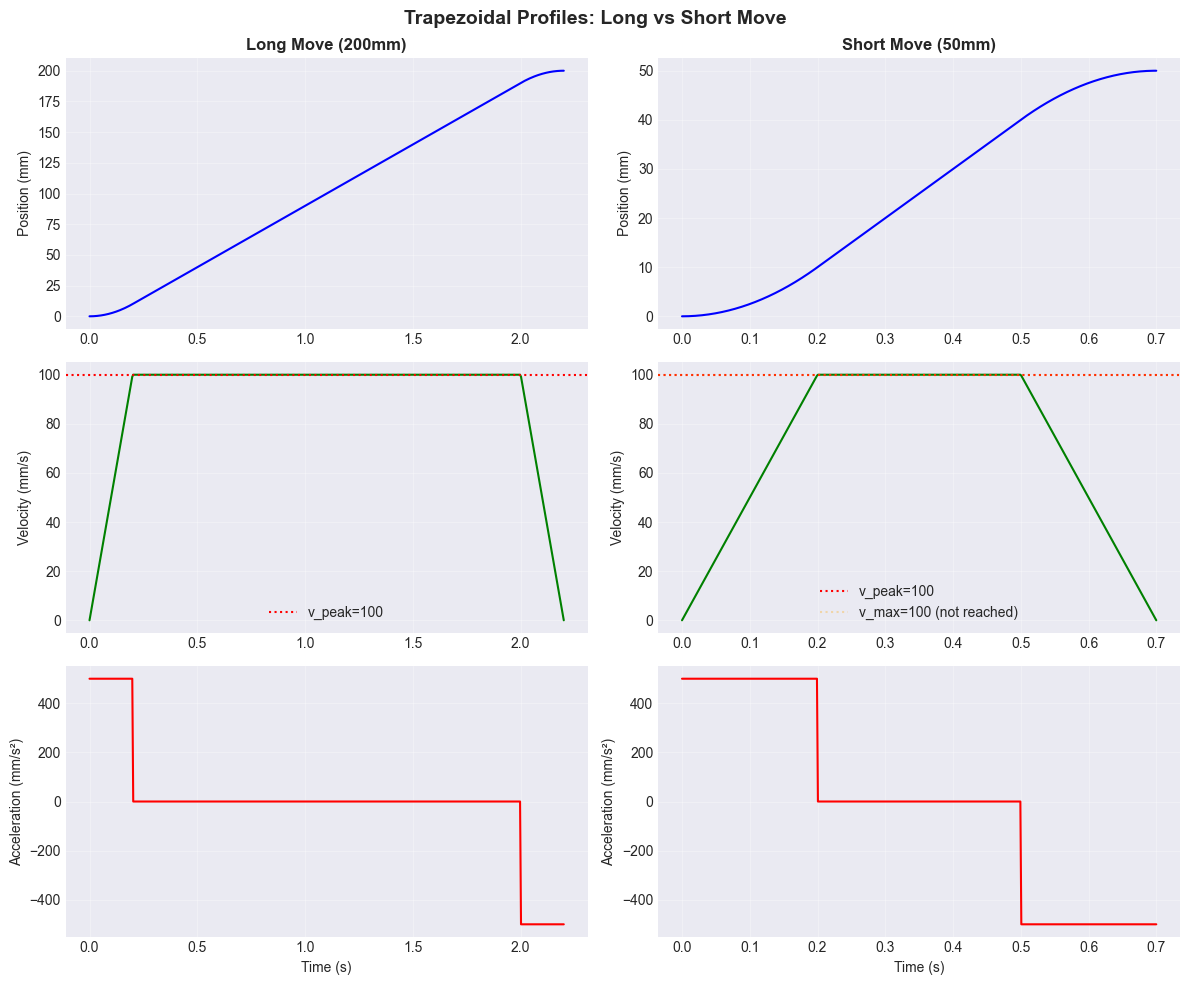


 Trapezoidal profiles generated!


In [4]:
# Trapezoidal Velocity Profile

def trap_profile(d, v_max, a_max):
 """Generate trapezoidal profile"""
 d_crit = v_max**2 / a_max
 
 if d >= d_crit:
 # Long move: reach v_max
 t1 = v_max / a_max
 d1 = 0.5 * a_max * t1**2
 d2 = d - 2*d1
 t2 = t1 + d2/v_max
 t3 = t2 + t1
 v_peak = v_max
 else:
 # Short move: triangular
 v_peak = np.sqrt(a_max * d)
 t1 = v_peak / a_max
 t2 = t1
 t3 = 2*t1
 
 # Generate arrays
 t = np.linspace(0, t3, 500)
 pos = np.zeros_like(t)
 vel = np.zeros_like(t)
 acc = np.zeros_like(t)
 
 for i, ti in enumerate(t):
 if ti <= t1:
 acc[i] = a_max
 vel[i] = a_max * ti
 pos[i] = 0.5 * a_max * ti**2
 elif ti <= t2:
 vel[i] = v_peak
 pos[i] = 0.5*a_max*t1**2 + v_peak*(ti-t1)
 else:
 t_d = ti - t2
 acc[i] = -a_max
 vel[i] = v_peak - a_max*t_d
 pos[i] = 0.5*a_max*t1**2 + v_peak*(t2-t1) + v_peak*t_d - 0.5*a_max*t_d**2
 
 return t, pos, vel, acc, v_peak, t1, t2, t3

# Example 1: Long move
t1, pos1, vel1, acc1, vp1, ta1, tb1, tc1 = trap_profile(200, 100, 500)

# Example 2: Short move
t2, pos2, vel2, acc2, vp2, ta2, tb2, tc2 = trap_profile(50, 100, 500)

print("Trapezoidal Velocity Profiles")
print(f"\nLong move (200mm): v_peak={vp1:.1f} mm/s, time={tc1:.2f}s")
print(f"Short move (50mm): v_peak={vp2:.1f} mm/s (< v_max), time={tc2:.2f}s")

# Plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Trapezoidal Profiles: Long vs Short Move', fontsize=14, fontweight='bold')

# Long move
axes[0,0].plot(t1, pos1, 'b-')
axes[0,0].set_ylabel('Position (mm)')
axes[0,0].set_title('Long Move (200mm)', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

axes[1,0].plot(t1, vel1, 'g-')
axes[1,0].axhline(vp1, color='r', linestyle=':', label=f'v_peak={vp1:.0f}')
axes[1,0].set_ylabel('Velocity (mm/s)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[2,0].plot(t1, acc1, 'r-')
axes[2,0].set_xlabel('Time (s)')
axes[2,0].set_ylabel('Acceleration (mm/s²)')
axes[2,0].grid(True, alpha=0.3)

# Short move
axes[0,1].plot(t2, pos2, 'b-')
axes[0,1].set_ylabel('Position (mm)')
axes[0,1].set_title('Short Move (50mm)', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

axes[1,1].plot(t2, vel2, 'g-')
axes[1,1].axhline(vp2, color='r', linestyle=':', label=f'v_peak={vp2:.0f}')
axes[1,1].axhline(100, color='orange', linestyle=':', alpha=0.3, label='v_max=100 (not reached)')
axes[1,1].set_ylabel('Velocity (mm/s)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

axes[2,1].plot(t2, acc2, 'r-')
axes[2,1].set_xlabel('Time (s)')
axes[2,1].set_ylabel('Acceleration (mm/s²)')
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Trapezoidal profiles generated!")

---
### What This Graph Tells You

**Long Move (top row):** The velocity profile is a proper **trapezoid** with three distinct phases:
1. **Acceleration phase:** Motor ramps up at maximum acceleration (limited by motor torque: $\tau = I\alpha$)
2. **Constant speed phase:** Motor cruises at maximum feed rate
3. **Deceleration phase:** Motor ramps down symmetrically

**Short Move (bottom row):** The move is too short to reach maximum speed! The velocity profile becomes **triangular** — the motor accelerates then immediately decelerates. This is common for small features.

**Acceleration Plots:** Notice the abrupt transitions between phases. In real CNC machines, these are smoothed using S-curve profiles to reduce mechanical vibration (jerk limiting).

**Key Observations:**
- Long moves are **speed-limited** (most time spent at $v_{max}$)
- Short moves are **acceleration-limited** (never reach $v_{max}$)
- Position vs. time is S-shaped (integral of trapezoidal velocity)
- Total move time: $T = \frac{v_{max}}{a_{max}} + \frac{D}{v_{max}}$ for long moves

> **Student Takeaway:** Real CNC machines NEVER change speed instantaneously. The trapezoidal velocity profile is the fundamental building block of ALL computerized motion control — from 3D printers to industrial robots to elevator systems.

# Practice Problems

## **Try These**

**Problem 1**: Move from (0,0,0) to (150,80,40) mm at F=60 mm/s. Find motor speeds and time.

**Problem 2**: Robot moves 250mm with v_max=150 mm/s, a_max=1000 mm/s². Find total time.

**Problem 3**: 3D printer helix: R=30mm, h=20mm (4 turns), F=40 mm/s. Find printing time.

**Problem 4**: Move 80mm with v_max=200 mm/s, a_max=800 mm/s². Will it reach v_max?

**Problem 5**: CNC router: (0,0,0)→(100,100,50) at F=50 mm/s. Motor limits: vₓ,ₘₐₓ=60, vᵧ,ₘₐₓ=60, vᵧ,ₘₐₓ=30 mm/s. Feasible?


In [5]:
# Practice Workspace

print("Practice Problems Workspace")
print("="*50)

print("\nProblem 1: Straight Line Move")
print("-"*40)
# Your solution here

print("\n\nProblem 2: Trapezoidal Profile")
print("-"*40)
# Your solution here

print("\n\nProblem 3: Helix")
print("-"*40)
# Your solution here

print("\n Work through the problems!")

Practice Problems Workspace

Problem 1: Straight Line Move
----------------------------------------


Problem 2: Trapezoidal Profile
----------------------------------------


Problem 3: Helix
----------------------------------------

 Work through the problems!


# Summary

## Key Formulas

| Concept | Formula |
|---------|--------|
| **3D Velocity** | $\mathbf{v} = v_x\hat{\mathbf{i}} + v_y\hat{\mathbf{j}} + v_z\hat{\mathbf{k}}$ |
| **Speed** | $v = \sqrt{v_x^2 + v_y^2 + v_z^2}$ |
| **Motor Speeds** | $\omega_x = v_x/p_x$ |
| **Accel Time** | $t_1 = v_m/a_m$ |
| **Accel Distance** | $d_1 = v_m^2/(2a_m)$ |
| **Short Move** | $v_{peak} = \sqrt{a_m \cdot d}$ |

## Fundamental Insights

1. **Cartesian Decoupling**: x, y, z axes are independent
2. **Direct Mapping**: Motor speeds = velocity components / pitch
3. **Tradeoff**: High velocity needs long accel distance
4. **Path Planning**: Geometric path → velocity profile → motor commands

## Connections

- **Unit 2**: Polar (rotating basis) vs Cartesian (fixed basis)
- **Unit 5 Preview**: Rigid body orientation, SCARA robots, delta printers
- **Unit 7**: Numerical ODE integration for dynamics

## What You've Mastered

 Decompose 3D motion into xyz components 
 Calculate motor speeds from toolpath 
 Generate trapezoidal velocity profiles 
 Understand acceleration constraints 
 Visualize 3D trajectories 

**Next**: Unit 4 Practical - Hands-on simulations!

---
**End of Lecture 3** 